# 03 ベースラインモデルの作成

このフェーズではモデルを作る前に比較基準を作る

> 最終的に作るモデルと比べて、何が良くなったのか？

を説明できるようにする

そのため、以下のベースラインを作る

1. 最頻クラス予測
2. 24時間前の天気をそのまま使う予測
3. RandomForestによる最初の機械学習モデル

この3つを比較することで、最低限超えるべき基準が見える

In [20]:
from pathlib import Path
import pandas as pd

import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
)
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score


## 1. 特徴量データを読み込む

`02_feature_engineering.ipynb`で保存した特徴量CSVを読み込む

In [21]:
feature_path = Path("./data/features_weather_24h.csv")

feature_df = pd.DataFrame()

if feature_path.exists():
    feature_df = pd.read_csv(feature_path, parse_dates=["datetime"])
else:
    print("先に02_feature_engineering.ipynbを実行してCSVを作成してください")

print(feature_df.shape)
display(feature_df.head())

(35051, 191)


,datetime,temperature,humidity,pressure,precipitation,no_rain,wind_speed,wind_speed_gn,cloud_amount,weather_code,...,wind_dir_南東,wind_dir_南西,wind_dir_東,wind_dir_東北東,wind_dir_東南東,wind_dir_西,wind_dir_西北西,wind_dir_西南西,wind_dir_静穏,wind_dir_nan
0,2021-01-01 02:00:00,0.4,46.0,1008.4,0.0,1,1.5,1,0.0,1.0,...,False,False,False,False,False,False,False,False,False,False
1,2021-01-01 03:00:00,-0.6,52.0,1008.0,0.0,1,1.1,1,0.0,1.0,...,False,False,False,False,False,False,True,False,False,False
2,2021-01-01 04:00:00,0.1,51.0,1007.8,0.0,1,1.8,1,0.0,1.0,...,False,False,False,False,False,False,False,False,False,False
3,2021-01-01 05:00:00,0.0,53.0,1007.8,0.0,1,0.6,1,0.0,1.0,...,False,False,False,False,False,False,False,False,False,False
4,2021-01-01 06:00:00,-0.4,58.0,1008.4,0.0,1,1.1,1,0.0,1.0,...,False,False,False,False,False,False,True,False,False,False


## 2. 時系列でtrain / testに分割する

時系列データでは、ランダム分割は避ける

ここでは、古い80%を学習、後ろ20%をテストとする

In [22]:
# 80%を学習、後ろ20%をテストとする
split_idx = int(len(feature_df) * 0.8)
train_df = feature_df.iloc[:split_idx].copy()
test_df = feature_df.iloc[split_idx:].copy()

print("train:", train_df["datetime"].min(), "~", train_df["datetime"].max(), train_df.shape)
print("test:", test_df["datetime"].min(), "~", test_df["datetime"].max(), test_df.shape)

def get_xy(df: pd.DataFrame):
    df = df.dropna(subset=["target_weather_class"])
    drop_cols = [
        "datetime",
        "target_weather_class",
    ]
    X = df.drop(columns=[c for c in drop_cols if c in feature_df.columns])
    y = df["target_weather_class"].astype(int)
    return X, y

X_train, y_train = get_xy(train_df)
X_test, y_test = get_xy(test_df)

print(X_train.shape, X_test.shape)

train: 2021-01-01 02:00:00 ~ 2024-03-14 18:00:00 (28040, 191)
test: 2024-03-14 19:00:00 ~ 2025-01-01 00:00:00 (7011, 191)
(28040, 189) (6987, 189)


## 3. ベースライン1: 最頻クラス予測

最頻クラス予測は、学習データで一番多い天気クラスだけを常に予測する

たとえば「晴れ」が一番多ければ、全部「晴れ」と予測する

これはかなり単純ですが、天気のようにクラス偏りがある問題では、意外とAccuracyが高く見えることがある

In [23]:
label = "most_frequent_baseline"
model = DummyClassifier(strategy="most_frequent")
model.fit(X_train, y_train)
pred = model.predict(X_test)

metrics_dummy = {
    "model": "dummy_most_frequent",
    "accuracy": accuracy_score(y_test, pred),
    "macro_f1": f1_score(y_test, pred, average="macro"),
    "weighted_f1": f1_score(y_test, pred, average="weighted"),
}

print(f"## {label}")
print(metrics_dummy)
print()
print(classification_report(y_test, pred, zero_division=0))

## most_frequent_baseline
{'model': 'dummy_most_frequent', 'accuracy': 0.5513095749248604, 'macro_f1': 0.142153335178522, 'weighted_f1': 0.39185247395711087}

              precision    recall  f1-score   support

           1       0.55      1.00      0.71      3852
           2       0.00      0.00      0.00      2100
           3       0.00      0.00      0.00       999
           5       0.00      0.00      0.00        33
           6       0.00      0.00      0.00         3

    accuracy                           0.55      6987
   macro avg       0.11      0.20      0.14      6987
weighted avg       0.30      0.55      0.39      6987



## 4. ベースライン2: 24時間前の天気をそのまま予測

天気には周期性があると仮定し、

> 24時間前の天気コード = 24時間後の天気コード

として予測するベースラインを作る

これは機械学習ではない割には、正答率は高い予測となる


In [24]:
pred_prev_24h = X_test["weather_class_lag_24h"].astype(int)

metrics_prev_24h = {
    "model": "previous_24h_weather",
    "accuracy": accuracy_score(y_test, pred_prev_24h),
    "macro_f1": f1_score(y_test, pred_prev_24h, average="macro"),
    "weighted_f1": f1_score(y_test, pred_prev_24h, average="weighted"),
}

metrics_prev_24h

{'model': 'previous_24h_weather',
 'accuracy': 0.44382424502647777,
 'macro_f1': 0.21504744169028336,
 'weighted_f1': 0.44370435567077476}

## 5. ベースライン3: RandomForest

最初の機械学習モデルとしてRandomForestを使うことにする

ここではモデルの強さよりも、まず「機械学習モデルがベースラインを超えられるか」を確認する

In [25]:
label = "random_forest_baseline"
rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1,
    class_weight="balanced_subsample",
)

rf.fit(X_train, y_train)
pred_rf = rf.predict(X_test)

metrics_rf = {
    "model": label,
    "accuracy": accuracy_score(y_test, pred_rf),
    "macro_f1": f1_score(y_test, pred_rf, average="macro"),
    "weighted_f1": f1_score(y_test, pred_rf, average="weighted")
}

print(f"## {label}")
print(metrics_rf)
print()
print(classification_report(y_test, pred_rf, zero_division=0))

## random_forest_baseline
{'model': 'random_forest_baseline', 'accuracy': 0.5451552883927293, 'macro_f1': 0.21167178207293852, 'weighted_f1': 0.4859810675366146}

              precision    recall  f1-score   support

           1       0.60      0.84      0.70      3852
           2       0.39      0.27      0.32      2100
           3       0.17      0.03      0.05       999
           5       0.00      0.00      0.00        33
           6       0.00      0.00      0.00         3

    accuracy                           0.55      6987
   macro avg       0.23      0.23      0.21      6987
weighted avg       0.47      0.55      0.49      6987



## 6. ベースライン結果の比較

ここで大事なのは、単に一番高いスコアを見ることではない

見るべきポイントは以下

- 最頻クラス予測より良いか
- 24時間前の天気コピーより良いか
- AccuracyだけでなくF1も改善しているか
- 雨など少ないクラスにも対応できているか

In [26]:
baseline_results = pd.DataFrame([
    metrics_dummy,
    metrics_prev_24h,
    metrics_rf,
])

display(baseline_results.sort_values("weighted_f1", ascending=False))

,model,accuracy,macro_f1,weighted_f1
2,random_forest_baseline,0.545155,0.211672,0.485981
1,previous_24h_weather,0.443824,0.215047,0.443704
0,dummy_most_frequent,0.551310,0.142153,0.391852


## 7. 混同行列を見る

Accuracyだけでは、どの天気を間違えているか判断できない
なので混同行列を見ることで、

- 晴れを曇と間違えやすい
- 雨を曇と間違えやすい
- 少ない天気コードはほぼ当たっていない

といった改善ポイントを見つけられる

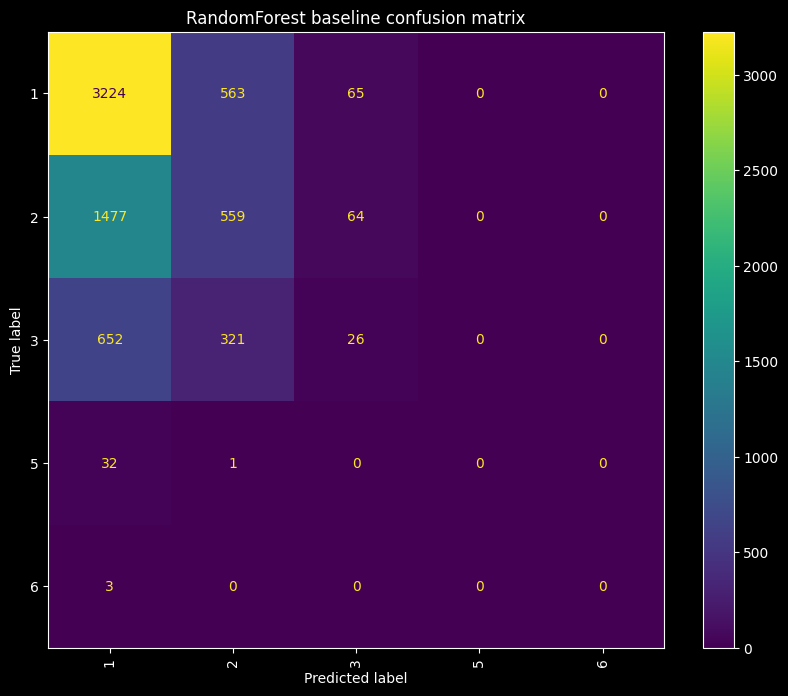

In [27]:
labels = sorted(y_test.unique())

cm = confusion_matrix(y_test, pred_rf, labels=labels)

fig, ax = plt.subplots(figsize=(10, 8))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
disp.plot(ax=ax, xticks_rotation=90, values_format="d")
plt.title("RandomForest baseline confusion matrix")
plt.show()